## Partie 4 : Introduction au traitement d'images

Dans cette partie, nous utiliserons principalement la bibliothèque [scikit-image](https://scikit-image.org/) spécialisée dans le traitement d'images. Pour l'installer avec pip :

In [1]:
!pip install -U scikit-image

   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.9 MB 212.4 kB/s eta 0:00:59
   - -------------------------------------- 0.5/12.9 MB 212.4 kB/s eta 0:00:59
   - -------------------------------------- 0.5/12.9 MB 212.4 kB/s eta 0

ou avec conda (ou mamba, en remplaçant `conda` par `mamba`) :

In [ ]:
# conda install scikit-image

Au début de votre code, importez les sous-packages suivants :

In [36]:
from skimage import exposure, color, filters, measure
import numpy as np
import matplotlib.pyplot as plt
import time

### 4.1 Ouverture, affichage et types d'images

**Exercice 4.1** Créez un dossier `images` dans le dossier contenant votre notebook. Ajoutez-y l'image `moon.tif`. Ensuite, ouvrez celle-ci au moyen de l'instruction :

Dimensions : (537, 358)
Type : uint8
Variable   Type       Data/Info
-------------------------------
MoonImg    str        ../Fichiers-pour-TP/Image/moon.tif
color      module     <module 'skimage.color' f<...>age\\color\\__init__.py'>
exposure   module     <module 'skimage.exposure<...>\\exposure\\__init__.py'>
filters    module     <module 'skimage.filters'<...>e\\filters\\__init__.py'>
measure    module     <module 'skimage.measure'<...>e\\measure\\__init__.py'>
moon       ndarray    537x358: 192246 elems, type `uint8`, 192246 bytes (187.740234375 kb)
np         module     <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
plt        module     <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>


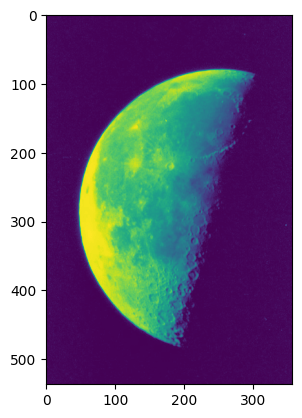

In [2]:
MoonImg = '../Fichiers-pour-TP/Image/moon.tif'
moon = plt.imread(MoonImg)
plt.imshow(moon)
# type(moon)
print(f"Dimensions : {moon.shape}")
print(f"Type : {moon.dtype}")
%whos

L'instruction `%whos` indiquera le nom, le type et la taille de l'image. On constate que sa taille est $537\times358$ et que ses éléments sont du type `'uint8'`. Cela indique qu'elle possède $256$ ($2^8$) niveaux de gris.

Visualisez cette image en niveaux de gris grâce aux instructions :

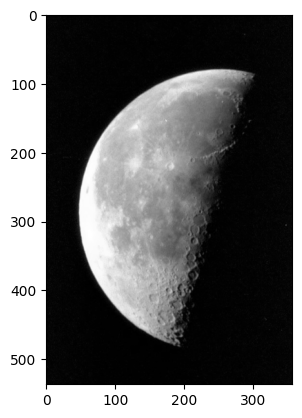

In [3]:
plt.imshow(moon, cmap='gray')
plt.show()

Placez un rectangle blanc de taille $10\times20$ dans le coin supérieur gauche de l'image et visualisez le résultat. Sauvez cette nouvelle image en utilisant la fonction `plt.imsave`. Assurez-vous que la colormap de l'image sauvée est en niveaux de gris.

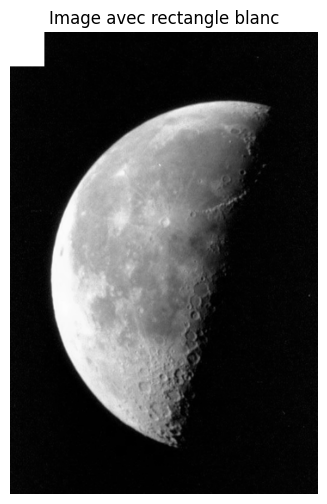

In [4]:
# 1. Importer les librairies et l'Image.
# Ceci est fait dans les cellules ci-dessus.

# 2. Convertir l'image en niveaux de gris si elle est en couleur
if len(moon.shape) == 3:  # Vérifie si l'image est en couleur
    image_gray = color.rgb2gray(moon)
    image_gray = (image_gray * 255).astype(np.uint8)
else:
    image_gray = moon.copy()

# 3. Créer un rectangle blanc de taille 10x20 dans le coin supérieur gauche
# Modifier les pixels correspondants
image_with_rectangle = image_gray.copy()
image_with_rectangle[:40, :40] = 255  # Valeur de 1.0 correspond au blanc en niveaux de gris normalisés

# 4. Afficher l'image avec le rectangle
plt.figure(figsize=(8, 6))
plt.imshow(image_with_rectangle, cmap='gray')
plt.title("Image avec rectangle blanc")
plt.axis('off')
plt.show()

# 5. Sauvegarder l'image modifiée en niveaux de gris
output_path = '../Fichiers-pour-TP/Images-creer-modifie/image_rectangle_grayscale.jpg'
plt.imsave(output_path, image_with_rectangle, cmap='gray')  # Conversion en 8 bits pour la sauvegarde

**Exercice 4.2** Ouvrez l'image `flowers.tif`.

- Quels sont le type de l'image, le type de ses éléments et la taille de l'image ?
- Sur quatre sous-figures, affichez l'image originale, sa composante rouge (R), sa composante verte (G) et sa composante bleue (B). Est-ce que ceci vous semble cohérent ? 
- Utilisez la fonction `measure.profile_line` pour visualiser les composantes R, G et B d'une ligne sur l'image.

Dimensions : (362, 500, 3)
Type : uint8


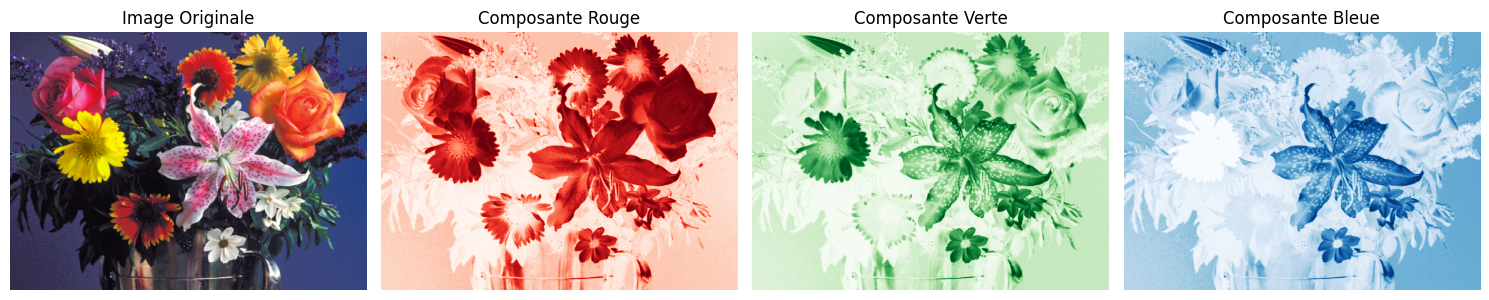

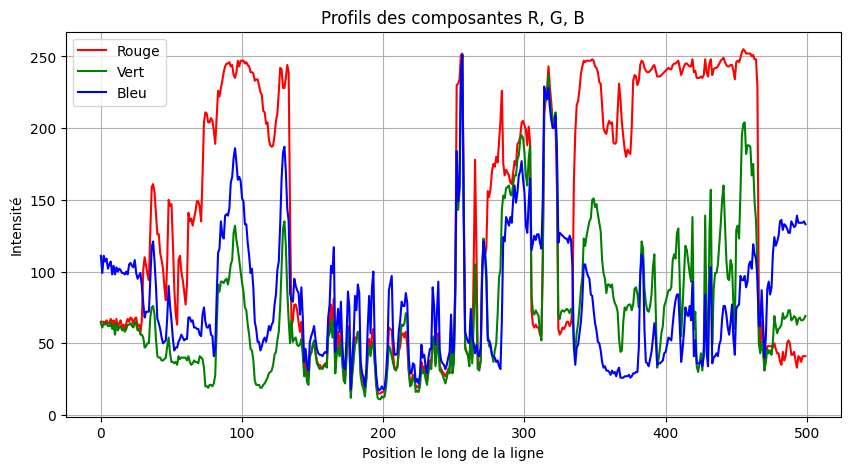

In [6]:
#---------- 1. On importe l'image et on récupère/affiche son Type et sa Taille. -----------
FlowerImg = '../Fichiers-pour-TP/Image/flowers.tif'
flowers = plt.imread(FlowerImg)
# plt.imshow(I2)
print(f"Dimensions : {flowers.shape}")
print(f"Type : {flowers.dtype}")

#---------- 2. On affiche l'image et ses composantes dans différentes sous-figures. -----------
# Vérifier si l'image est en couleur
if len(flowers.shape) != 3 or flowers.shape[2] != 3:
    raise ValueError("L'image chargée n'est pas une image couleur avec trois canaux.")

# Extraire les composantes Rouge, Verte et Bleue
red_component = flowers[:, :, 0]   # Canal rouge
green_component = flowers[:, :, 1] # Canal vert
blue_component = flowers[:, :, 2]  # Canal bleu

# Créer les sous-figures
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Afficher l'image originale
axes[0].imshow(flowers)
axes[0].set_title("Image Originale")
axes[0].axis('off')

# Afficher la composante Rouge
axes[1].imshow(red_component, cmap='Reds')
axes[1].set_title("Composante Rouge")
axes[1].axis('off')

# Afficher la composante Verte
axes[2].imshow(green_component, cmap='Greens')
axes[2].set_title("Composante Verte")
axes[2].axis('off')

# Afficher la composante Bleue
axes[3].imshow(blue_component, cmap='Blues')
axes[3].set_title("Composante Bleue")
axes[3].axis('off')

# Ajuster l'espacement
plt.tight_layout()
plt.show()

#--------- 3. On va afficher les composantes RGB uniquement sur une ligne de l'image. --------------
# Définir les points de la ligne (ligne horizontale par exemple)
start_point = (100, 0)  # (y, x) : Départ en haut à gauche de la ligne
end_point = (100, flowers.shape[1] - 1)  # (y, x) : Fin à droite de la même ligne

# Extraire les profils pour les composantes R, G et B
red_profile = measure.profile_line(flowers[:, :, 0], src=start_point, dst=end_point, mode='constant')
green_profile = measure.profile_line(flowers[:, :, 1], src=start_point, dst=end_point, mode='constant')
blue_profile = measure.profile_line(flowers[:, :, 2], src=start_point, dst=end_point, mode='constant')

# Créer les sous-figures pour visualiser les profils
x = np.linspace(0, len(red_profile) - 1, len(red_profile))

plt.figure(figsize=(10, 5))

# Profils de couleur
plt.plot(x, red_profile, 'r-', label='Rouge')
plt.plot(x, green_profile, 'g-', label='Vert')
plt.plot(x, blue_profile, 'b-', label='Bleu')

plt.title("Profils des composantes R, G, B")
plt.xlabel("Position le long de la ligne")
plt.ylabel("Intensité")
plt.legend()
plt.grid()
plt.show()

**Exercice 4.3** Créez et affichez des carrés de taille $400\times 400$ des couleurs suivantes :

- rouge d'intensité maximale ;
- vert d'intensité maximale ;
- bleu d'intensité maximale ;
- rouge et vert d'intensité maximale ;
- rouge et bleu d'intensité maximale ;
- vert et bleu d'intensité maximale ;
- rouge, vert et bleu d'intensité maximale ;
- bleu se trouvant dans le coin inférieur droit de l'image `flowers.tif`.

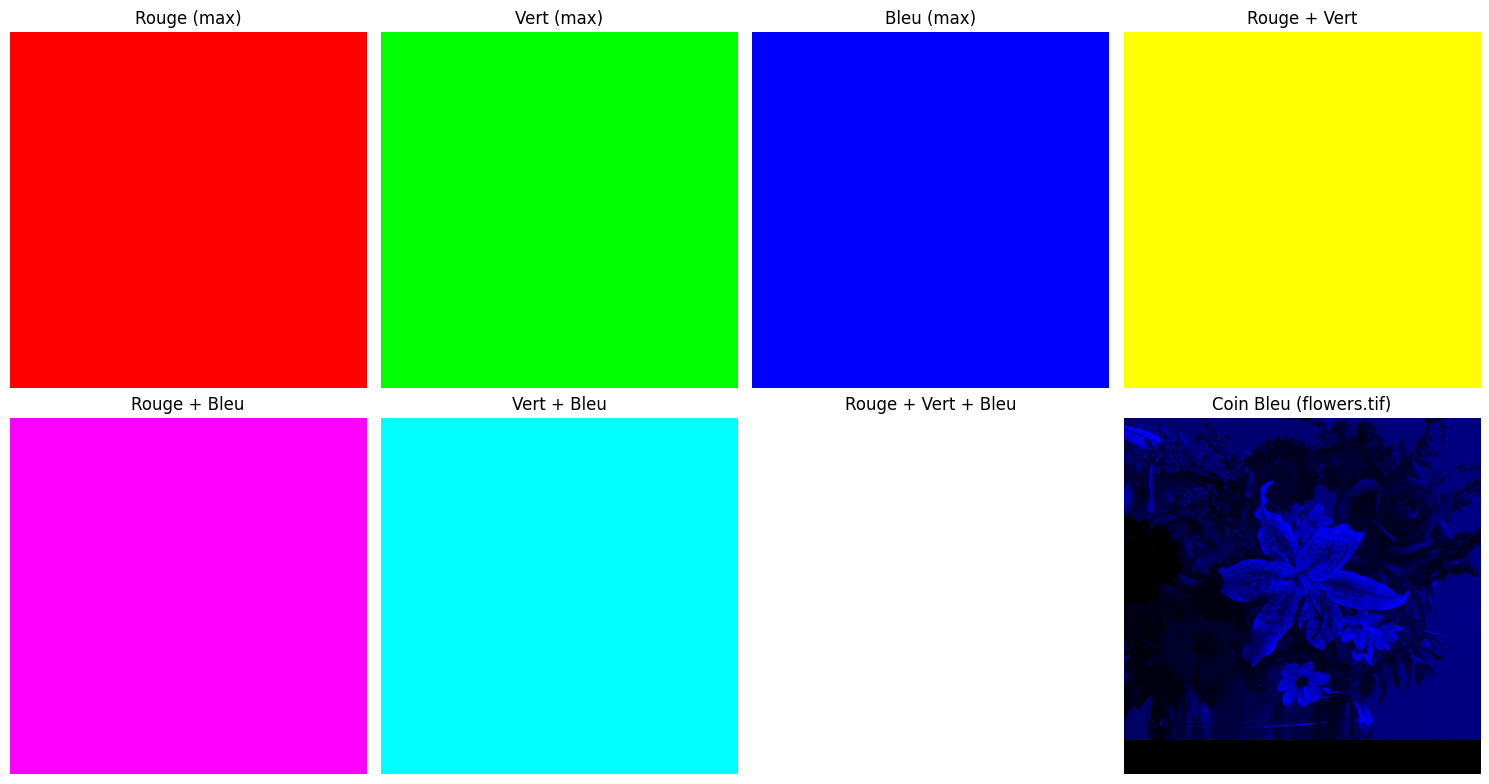

In [7]:
# Dimensions de l'image
height, width = 400, 400

# Couleurs avec intensité maximale
rouge = np.zeros((height, width, 3), dtype=np.uint8)
rouge[:, :, 0] = 255

vert = np.zeros((height, width, 3), dtype=np.uint8)
vert[:, :, 1] = 255

bleu = np.zeros((height, width, 3), dtype=np.uint8)
bleu[:, :, 2] = 255

rouge_vert = np.zeros((height, width, 3), dtype=np.uint8)
rouge_vert[:, :, 0] = 255
rouge_vert[:, :, 1] = 255

rouge_bleu = np.zeros((height, width, 3), dtype=np.uint8)
rouge_bleu[:, :, 0] = 255
rouge_bleu[:, :, 2] = 255

vert_bleu = np.zeros((height, width, 3), dtype=np.uint8)
vert_bleu[:, :, 1] = 255
vert_bleu[:, :, 2] = 255

rouge_vert_bleu = np.ones((height, width, 3), dtype=np.uint8) * 255


# Extraire le coin inférieur droit de la composante bleue de l'image 'Flower.tif'
corner_blue = flowers[-min(height, flowers.shape[0]):, -min(width, flowers.shape[1]):, 2]

# Ajuster les dimensions pour correspondre à (400x400)
flowers_blue = np.zeros((height, width, 3), dtype=np.uint8)
flowers_blue[:corner_blue.shape[0], :corner_blue.shape[1], 2] = corner_blue

# Afficher les images
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.ravel()

images = [rouge, vert, bleu, rouge_vert, rouge_bleu, vert_bleu, rouge_vert_bleu, flowers_blue]
titles = [
    "Rouge (max)",
    "Vert (max)",
    "Bleu (max)",
    "Rouge + Vert",
    "Rouge + Bleu",
    "Vert + Bleu",
    "Rouge + Vert + Bleu",
    "Coin Bleu (flowers.tif)",
]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Exercice 4.4** Ouvrez l'image `flowers.tif`.

- Constatez que les éléments de l'image `flowers.tif` sont de type `'uint8'`.
- Transformez le type des éléments en `'float64'` grâce à la méthode `astype`. Dans quel intervalle sont compris les niveaux de couleurs ? L'image s'affiche-t-elle correctement ? Si pas, que devrait-on ajouter comme étape pour obtenir le même résultat qu'avec l'image originale en `'uint8'` ? Dans quel intervalle sont maintenant compris les niveaux de couleurs ?

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Type initial des éléments : uint8
Intervalle des niveaux de couleurs initiaux : [0, 255]
Type après conversion : float64
Intervalle des niveaux de couleurs après conversion : [0.0, 255.0]


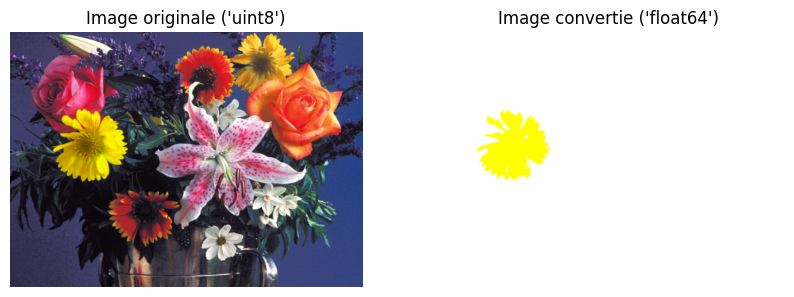

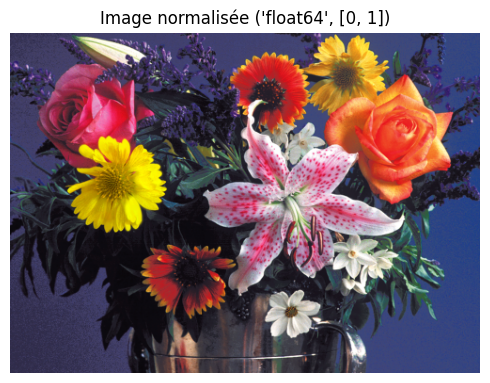

Intervalle des niveaux de couleurs après normalisation : [0.0, 1.0]


In [12]:
# Afficher les informations initiales sur l'image
print(f"Type initial des éléments : {flowers.dtype}")
print(f"Intervalle des niveaux de couleurs initiaux : [{flowers.min()}, {flowers.max()}]")

# Transformation en float64
flowers_float = flowers.astype('float64')

# Afficher les informations après conversion
print(f"Type après conversion : {flowers_float.dtype}")
print(f"Intervalle des niveaux de couleurs après conversion : [{flowers_float.min()}, {flowers_float.max()}]")

# Afficher l'image après conversion (sans modification)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Image originale ('uint8')")
plt.imshow(flowers)
plt.axis('off')

# On tente d'afficher l'image transformée au niveau des intervalles de niveau de couleurs
plt.subplot(1, 2, 2)
plt.title("Image convertie ('float64')")
plt.imshow(flowers_float)  # Tentative d'affichage
plt.axis('off')

# -------------- On règle le problème d'affichage ------------------

# Normalisation des valeurs dans l'intervalle [0, 1]
flowers_normalized = flowers_float / 255.0

# Afficher l'image après normalisation
plt.figure(figsize=(5, 5))
plt.title("Image normalisée ('float64', [0, 1])")
plt.imshow(flowers_normalized)
plt.axis('off')

plt.tight_layout()
plt.show()

# Afficher l'intervalle des valeurs normalisées
print(f"Intervalle des niveaux de couleurs après normalisation : [{flowers_normalized.min()}, {flowers_normalized.max()}]")

### Explications ex 4.4 :  
- L'image n'est pas affichée correctement car dans le format `uint8` les valeurs de l'intervalle sont comprise entre `[0, 255]` alors qu'en `float64` l'intervalle est `[0, 1]`.
- Lorsque je convertit en **float64** sans normaliser, les valeurs d'intervalles sont comme pour le type entier **uint8** `[0.0, 255.0]` alors qu'ils ne travaillent pas dans le même intervalle.

**Exercice 4.5** Que signifient contraste, histogramme, brillance (<i>brightness</i>) et correction gamma ?
Comment corriger une image par ajustement d'intensité ou par égalisation de l'histogramme ?
Utilisez la fonction `exposure.equalize_hist` pour améliorer l'image `pout.tif` par correction gamma (testez différentes valeurs pour le paramètre `gamma`).

Type initial : uint8
Intervalle initial : [74, 224]


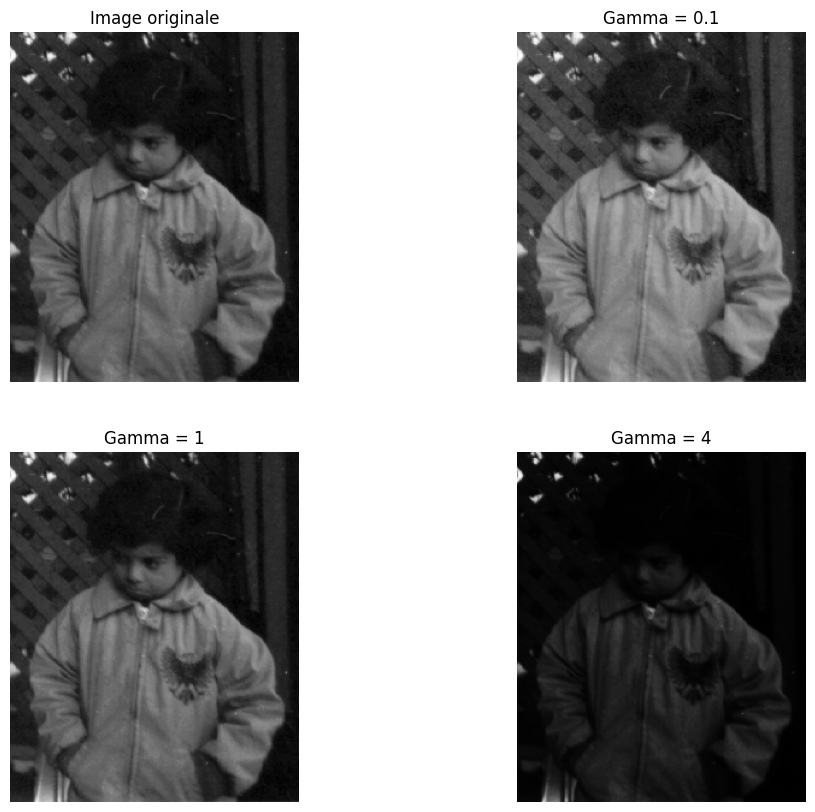

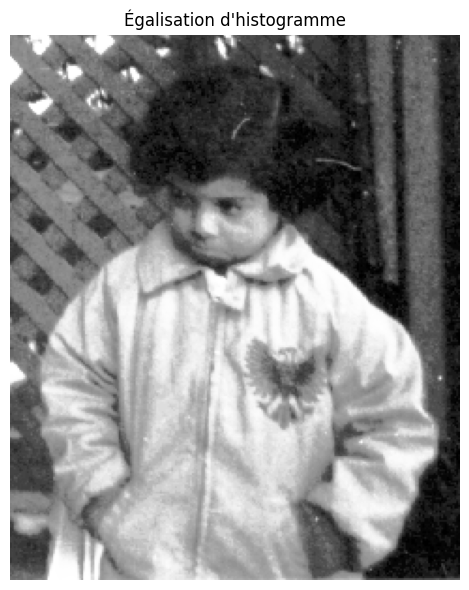

In [14]:
# Charger l'image pout.tif
PoutImg = '../Fichiers-pour-TP/Image/pout.tif'
pout = plt.imread(PoutImg)

# Vérifier le type et l'intervalle
print(f"Type initial : {pout.dtype}")
print(f"Intervalle initial : [{pout.min()}, {pout.max()}]")

# Normaliser l'image pour travailler dans l'intervalle [0, 1]
pout_norm = pout / 255.0

# Appliquer la correction gamma avec différentes valeurs
gamma_values = [0.1, 1, 4]  # Testez différentes valeurs
corrected_images = [exposure.adjust_gamma(pout_norm, gamma) for gamma in gamma_values]

# Appliquer l'égalisation d'histogramme
equalized_image = exposure.equalize_hist(pout_norm)

# Afficher les résultats
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# Image originale
axes[0].imshow(pout_norm, cmap='gray')
axes[0].set_title("Image originale")
axes[0].axis('off')

# Images corrigées par gamma
for i, gamma in enumerate(gamma_values):
    axes[i + 1].imshow(corrected_images[i], cmap='gray')
    axes[i + 1].set_title(f"Gamma = {gamma}")
    axes[i + 1].axis('off')

# Image après égalisation d'histogramme
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(equalized_image, cmap='gray')
ax.set_title("Égalisation d'histogramme")
ax.axis('off')

plt.tight_layout()
plt.show()

### Explications ex 4.5 :
- Le **contraste** : Cela représente la différence entre les zones `sombres` et les zones `claires` d'une image. Un contraste **élevé** met en évidence les `différences`, tandis qu'un contraste **faible** donne une image `"terne"`.
- L'**Histogramme** : L'histogramme est une `représentation graphique` de la distribution des niveaux d'intensité des pixels dans une image (de **0 à 255** pour les images en `uint8`). Il aide à visualiser les zones sur ou sous-exposées.
- La **Brillance** : La brillance correspond à `l'intensité globale` de l'image. **Augmenter** ou **diminuer** la brillance revient à **ajouter** ou **soustraire** une `constante` à tous les pixels de l'image.
- La **Correction Gamma** : La correction gamma `ajuste les niveaux d'intensité` des pixels selon une fonction **non linéaire**, ce qui permet de modifier la perception de la luminosité sans altérer le contraste de manière significative.

  - La formule utilisée est : 𝐼corrige = 𝐼original^gamma​
 
  - Un gamma < 1 **augmente** la luminosité, un gamma > 1 la **diminue**.

- L'**égalisation d'histogramme** : Cette technique `redistribue` les niveaux d'intensité pour obtenir un histogramme plus **uniforme**, **augmentant** ainsi le **contraste** de l'image.

### 4.2 Opérations arithmétiques sur une image

Les opérations arithmétiques peuvent être effectuées uniquement sur des images dont les éléments sont de type `float`. Pensez donc à utiliser systématiquement `astype` après l'import de votre image.

**Exercice 4.6** Ouvrez l'image `flowers.tif`. Ajoutez la valeur 200 à tous les pixels de l'image et visualisez le résultat. Qu'observez-vous ?

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..1.5].


Intervalle des valeurs après addition et SANS remise à l'échelle : [0.5, 1.5]
Intervalle des valeurs après addition et AVEC remise à l'échelle : [0.5, 1.0]


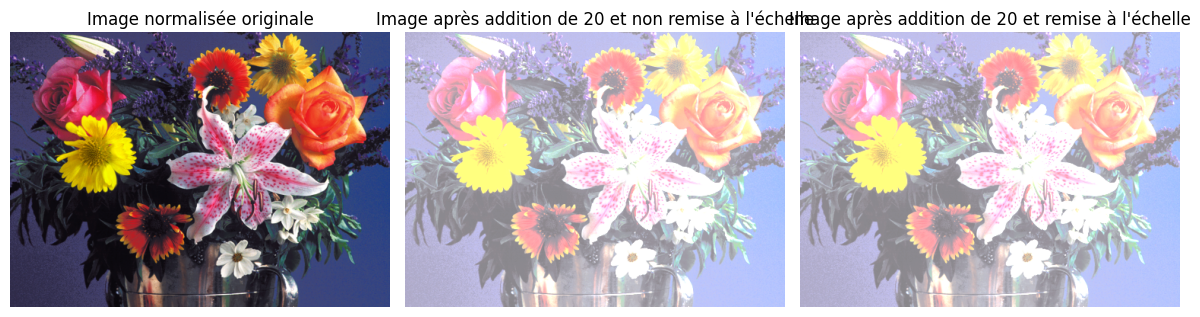

In [31]:
# L'import et la normalisation de l'image ont déjà été fait dans l'exercice précédent donc pas besoin de le refaire

# Ajouter une constante (200) à tous les pixels
# flowers_modified = flowers + 100

# # Transformation en float64
# flowers_float_modified = flowers_modified.astype('float64')

# # Normalisation des valeurs dans l'intervalle [0, 1]
# flowers_normalized_modified = flowers_float / 255.0

# # Remise à l'échelle dans un intervalle [0, 1]
# flowers_clipped = np.clip(flowers_normalized_modified, 0, 1)

# Ajouter une constante (200) à tous les pixels
flowers_modified = flowers_normalized + 0.5

# Remise à l'échelle dans un intervalle [0, 1]
flowers_clipped = np.clip(flowers_modified, 0, 1)

# Vérifier l'intervalle des valeurs après addition
print(f"Intervalle des valeurs après addition et SANS remise à l'échelle : [{flowers_modified.min()}, {flowers_modified.max()}]")
print(f"Intervalle des valeurs après addition et AVEC remise à l'échelle : [{flowers_clipped.min()}, {flowers_clipped.max()}]")

# Visualiser les images avant et après modification
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(flowers_normalized, cmap='gray')
axes[0].set_title("Image normalisée originale")
axes[0].axis('off')

axes[1].imshow(flowers_modified, cmap='gray')
axes[1].set_title("Image après addition de 20 et non remise à l'échelle")
axes[1].axis('off')

axes[2].imshow(flowers_clipped, cmap='gray')
axes[2].set_title("Image après addition de 20 et remise à l'échelle")
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Explication ex 4.6 :  
 - **Image originale** : elle est dans un intervalle `[0, 1]` car en **Float64**.
 - **Image modifiée** : elle est toujours dans un intervalle `[0, 1]` donc si je rajoute une constante plus grande que **1** l'image se retrouve toute blanche.
 - **Image clipped** : On remet à l'échelle dans l'intervalle `[0, 1]` afin de ne pas dépasser les valeurs de l'intervalle.

**Exercice 4.7** Affichez l'image `flowers.tif` en niveaux de gris sachant que la luminance (selon la recommandation UIT-R BT 601) vaut $0{,}299\times R + 0{,}587\times G + 0{,}114\times B$ où $R$, $G$, $B$ sont les matrices représentant les composantes R, G et B de l'image originale. Vous pouvez faire cela manuellement ou à l'aide de la fonction `np.dot`. Comparez votre résultat avec celui obtenu au moyen de la fonction `color.rgb2gray`.

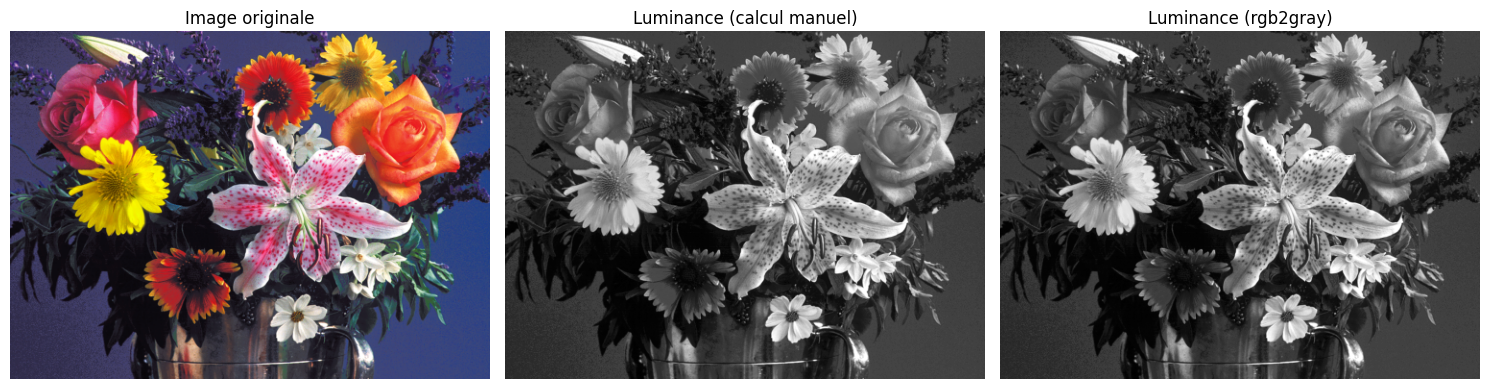

Différence maximale entre les deux méthodes : 0.08077607843137247


In [32]:
# Le chargement de l'image à déjà été effectué plus haut

# Séparer les composantes R, G et B
R = flowers[:, :, 0]
G = flowers[:, :, 1]
B = flowers[:, :, 2]

# Calculer la luminance manuellement
luminance_manual = 0.299 * R + 0.587 * G + 0.114 * B

# Normaliser la luminance pour la mettre dans l'intervalle [0, 1]
luminance_manual_normalized = luminance_manual / 255.0

# Utiliser la fonction color.rgb2gray
luminance_rgb2gray = color.rgb2gray(flowers)

# Afficher les résultats
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(flowers)
axes[0].set_title("Image originale")
axes[0].axis('off')

axes[1].imshow(luminance_manual_normalized, cmap='gray')
axes[1].set_title("Luminance (calcul manuel)")
axes[1].axis('off')

axes[2].imshow(luminance_rgb2gray, cmap='gray')
axes[2].set_title("Luminance (rgb2gray)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Vérifier si les deux résultats sont similaires
difference = np.abs(luminance_manual_normalized - luminance_rgb2gray)
print(f"Différence maximale entre les deux méthodes : {np.max(difference)}")

### Explications ex 4.7 :
L'image pour laquelle la **Luminance** à été calculé `manuellement` semble un peu plus claire que l'image pour laquelle la **Luminance** à été calculé avec la fonction `rgb2gray`.

**Exercice 4.8** Visualisez l'image `moon.tif` en 3D (pixels `x`, `y` et le niveau de gris) en utilisant les fonctions `np.meshgrid` et `plot_surface` :

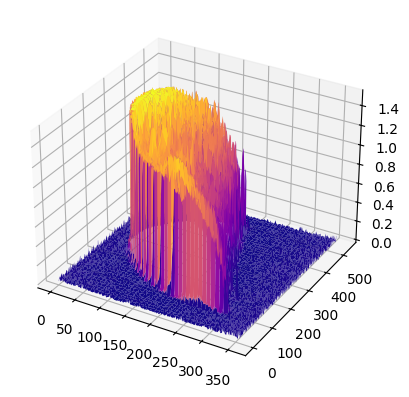

In [35]:
# I    = plt.imread('images/moon.tif')
moon = moon.astype(float)/255  # Normalisation
l, c = moon.shape  # Récupération des dimensions de l'image
x, y = np.meshgrid(np.arange(c), np.arange(l))  # Création d'une grille avec des axes x et y pour représenter chaque pixel

fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')  # Création de la figure 3D

ax.plot_surface(x, y, moon, cmap='plasma')
plt.show()

On peut changer la colormap grâce à l'argument `cmap`.

**Exercice 4.9** Ouvrez l'image `moon.tif`. Coloriez en noir chaque pixel de l'image au moyen des trois programmes suivants. Comparez le temps d'exécution de chacun de ces programmes. Vous constatez, une fois de plus, l'intérêt de passer par le calcul vectoriel.

In [37]:
# I = plt.imread('images/moon.tif')
J = moon.copy()

# Programme 1
t1_Start = time.time()
J[:, :]  = 0
t1_End   = time.time()

print("Temps d'exécution du programme 1 : ", t1_End-t1_Start)
             
# Programme 2
t2_Start = time.time()
for i in range(J.shape[0]):
    J[i, :] = 0
t2_End = time.time()

print("Temps d'exécution du programme 2 : ", t2_End-t2_Start)

# Programme 3
t3_Start = time.time()
for i in range(J.shape[0]):
    for j in range(J.shape[1]):
        J[i, j] = 0
t3_End = time.time()

print("Temps d'exécution du programme 3 : ", t3_End-t3_Start)

Temps d'exécution du programme 1 :  0.0
Temps d'exécution du programme 2 :  0.0029914379119873047
Temps d'exécution du programme 3 :  0.07999277114868164


**Exercice 4.10** L'image `diapo1.jpg` provient d'une ancienne diapositive. Elle est trop rouge. Corrigez-la. Faites de même avec l'image `diapo2.jpg`. 

Type initial : uint8
Intervalle initial : [0, 255]


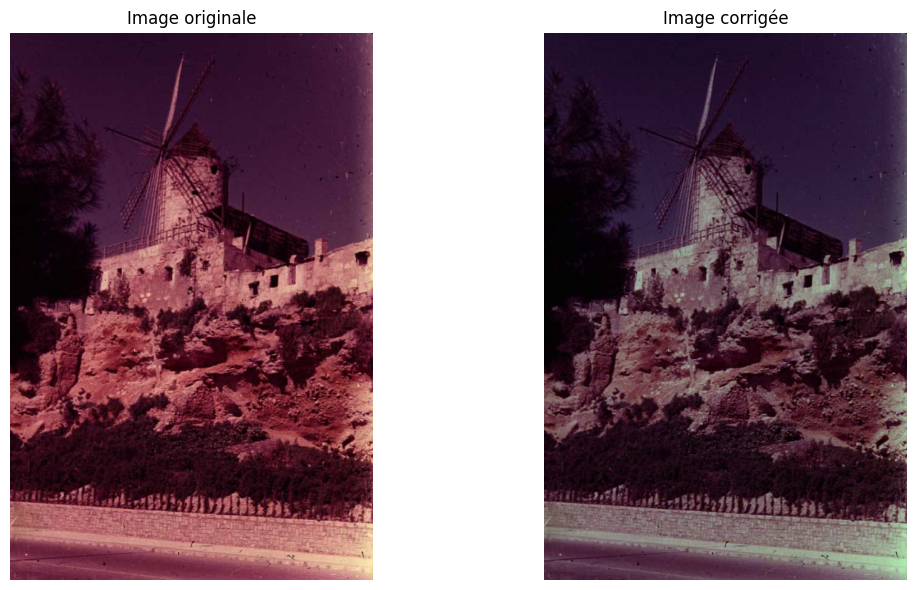

In [41]:
# Charger l'image pout.tif
Diapo1Img = '../Fichiers-pour-TP/Image/diapo1.jpg'
diapo1 = plt.imread(Diapo1Img)

# Vérifier le type et l'intervalle INITIALE
print(f"Type initial : {diapo1.dtype}")
print(f"Intervalle initial : [{diapo1.min()}, {diapo1.max()}]")

diapo1_float = diapo1.astype('float64')

# Normaliser l'image pour travailler dans l'intervalle [0, 1]
# diapo1_normalized = diapo1_float / 255.0

# Vérifier le type et l'intervalle FINALE
# print(f"Type initial : {diapo1_normalized.dtype}")
# print(f"Intervalle initial : [{diapo1_normalized.min()}, {diapo1_normalized.max()}]")

# --------------------------------------------------------
# Décomposer les canaux
red = diapo1_float[:, :, 0]
green = diapo1_float[:, :, 1]
blue = diapo1_float[:, :, 2]

# Réduire l'intensité du rouge
red_corrected = red * 0.7  # Réduction de 30% de l'intensité du rouge

# Recomposer l'image
corrected_image = np.stack((red_corrected, green, blue), axis=-1)

# Convertir en uint8 pour sauvegarder
corrected_image_uint8 = corrected_image.astype('uint8')

# Afficher l'image originale et corrigée
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(diapo1)
axes[0].set_title("Image originale")
axes[0].axis("off")

axes[1].imshow(corrected_image_uint8)
axes[1].set_title("Image corrigée")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Sauvegarder l'image corrigée
# io.imsave("diapo1_corrigee.jpg", corrected_image_uint8)
output_path = '../Fichiers-pour-TP/Images-creer-modifie/image_rectangle_grayscale.jpg'
plt.imsave(output_path, corrected_image_uint8, cmap='gray')  # Conversion en 8 bits pour la sauvegarde


### Explications ex 4.8 :
Dans cet exercice on n'a **pas besoin de normaliser** l'image après l'avoir formatté en `float64` car :
  - Nous la repassons en format `uint8` avant de l'afficher donc pas besoin de changer l'échelle car on ne risque pas de dépasser l'intervalle du format finale `unint8` (`[0, 255]`).
  - Faire une normalisation altère **toute** l'image en la remettant à l'échelle et en **changeant les proportions**. Cela peut affecter les effets de correction opéré sur l'image.
  
**Quand devrait-on normaliser une image ?**  
- Si on effectue des opérations qui modifient toute l'image (ajout, multiplication globale, ajustement gamma, etc.), car les valeurs peuvent dépasser la plage `[0,1]`.
- Pour afficher ou sauvegarder une image en `float64`, car les bibliothèques comme `matplotlib` et `skimage` supposent souvent que les images en `float64` sont normalisées dans `[0,1]`.